# 06 — Fairness Analysis
## FairLend-Africa Research Project

Examines whether the model produces equitable outcomes
across demographic groups. We evaluate three fairness
criteria from the algorithmic fairness literature:

1. **Demographic parity** — equal positive prediction rates
   across groups (Dwork et al., 2012)
2. **Equal opportunity** — equal true positive rates (recall)
   across groups (Hardt et al., 2016)
3. **Predictive parity** — equal precision across groups

We do NOT use demographic features as model inputs.
This analysis audits whether behavioral features
inadvertently serve as demographic proxies.

Note: perfect fairness across all three criteria
simultaneously is mathematically impossible when
base rates differ across groups (Chouldechova, 2017).
We acknowledge this limitation explicitly.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
import json
from pathlib import Path

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 130

Path("../artifacts/fairness").mkdir(parents=True, exist_ok=True)

In [2]:
pipeline = joblib.load("../artifacts/model/pipeline.pkl")

with open("../artifacts/model/threshold.json") as f:
    THRESHOLD = json.load(f)["optimal_threshold"]

FEATURE_COLS = [
    "monthly_txn_count", "avg_txn_amount_usd", "wallet_balance_trend",
    "airtime_recharge_freq", "airtime_avg_amount_usd",
    "has_savings_account", "savings_consistency_score", "monthly_savings_usd",
    "has_prior_loan", "prior_loan_repayment_rate", "days_late_avg",
    "network_diversity_score", "bill_payment_regularity",
    "merchant_payment_count", "loan_amount_requested_usd", "loan_duration_weeks",
    "txn_intensity", "savings_commitment_ratio", "airtime_stability",
    "no_prior_loan_flag",
]

# Load full dataset to get demographic attributes for test rows
df_full = pd.read_csv("../data/processed/fairlend_processed.csv")
X_test  = pd.read_csv("../artifacts/model/X_test.csv")
y_test  = pd.read_csv("../artifacts/model/y_test.csv").squeeze()

# Match demographic attributes to test set using index alignment
df_test = df_full.loc[X_test.index].copy()
df_test["y_true"] = y_test.values

y_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= THRESHOLD).astype(int)

df_test["y_pred"]  = y_pred
df_test["y_proba"] = y_proba

print(f"Test set size: {len(df_test):,}")
print(f"Demographic columns: {['region','gender','age','occupation']}")
print(f"\nGroup counts:")
for col in ["region", "gender"]:
    print(f"\n  {col}:")
    print(df_test[col].value_counts().to_string())

Test set size: 2,000
Demographic columns: ['region', 'gender', 'age', 'occupation']

Group counts:

  region:
region
West Africa        703
East Africa        590
Southern Africa    394
Central Africa     313

  gender:
gender
Male                 1046
Female                872
Prefer not to say      82


### 1. Fairness metrics computation
We compute per-group metrics for each protected attribute.
The key metrics are:
- **Selection rate** (demographic parity numerator)
- **TPR / Recall** (equal opportunity numerator)
- **Precision** (predictive parity numerator)
- **ROC-AUC** (overall discrimination ability)

In [3]:
def compute_group_metrics(df, group_col):
    """
    Compute fairness-relevant classification metrics
    for each group within a demographic column.
    """
    rows = []
    for group_val, grp in df.groupby(group_col):
        y_true_g = grp["y_true"]
        y_pred_g = grp["y_pred"]
        y_prob_g = grp["y_proba"]

        # Skip groups too small for reliable metrics
        if len(grp) < 30:
            continue

        tn, fp, fn, tp = confusion_matrix(
            y_true_g, y_pred_g, labels=[0, 1]
        ).ravel()

        n        = len(grp)
        pos_rate = y_true_g.mean()  # base rate in this group
        sel_rate = y_pred_g.mean()  # selection rate (demographic parity)
        tpr      = tp / (tp + fn) if (tp + fn) > 0 else np.nan  # recall / equal opportunity
        fpr      = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        prec     = tp / (tp + fp) if (tp + fp) > 0 else np.nan  # predictive parity
        f1       = (2 * prec * tpr / (prec + tpr)
                    if (prec + tpr) > 0 else np.nan)
        try:
            auc = roc_auc_score(y_true_g, y_prob_g)
        except Exception:
            auc = np.nan

        rows.append({
            "group":         str(group_val),
            "n":             n,
            "base_rate":     round(pos_rate, 4),
            "selection_rate":round(sel_rate, 4),
            "TPR_recall":    round(tpr,      4),
            "FPR":           round(fpr,      4),
            "precision":     round(prec,     4),
            "f1":            round(f1,       4),
            "roc_auc":       round(auc,      4),
        })

    result_df = pd.DataFrame(rows).set_index("group")

    # Compute disparity ratios relative to the group with highest metric
    for metric in ["selection_rate", "TPR_recall", "precision"]:
        max_val = result_df[metric].max()
        result_df[f"{metric}_disparity"] = (
            result_df[metric] / max_val
        ).round(4)

    return result_df


print("compute_group_metrics() defined.")

compute_group_metrics() defined.


In [4]:
fairness_region = compute_group_metrics(df_test, "region")
fairness_gender = compute_group_metrics(df_test, "gender")

print("=" * 65)
print("FAIRNESS METRICS BY REGION")
print("=" * 65)
print(fairness_region.to_string())

print("\n" + "=" * 65)
print("FAIRNESS METRICS BY GENDER")
print("=" * 65)
print(fairness_gender.to_string())

# Save tables
fairness_region.to_csv("../artifacts/fairness/fairness_by_region.csv")
fairness_gender.to_csv("../artifacts/fairness/fairness_by_gender.csv")
print("\n✓ Saved fairness tables")

FAIRNESS METRICS BY REGION
                   n  base_rate  selection_rate  TPR_recall  FPR  precision      f1  roc_auc  selection_rate_disparity  TPR_recall_disparity  precision_disparity
group                                                                                                                                                            
Central Africa   313     0.7604             1.0         1.0  1.0     0.7604  0.8639   0.6994                       1.0                   1.0               0.9888
East Africa      590     0.7373             1.0         1.0  1.0     0.7373  0.8488   0.7054                       1.0                   1.0               0.9588
Southern Africa  394     0.7690             1.0         1.0  1.0     0.7690  0.8694   0.7235                       1.0                   1.0               1.0000
West Africa      703     0.7610             1.0         1.0  1.0     0.7610  0.8643   0.7270                       1.0                   1.0               0.9896



### 2. Demographic parity analysis
Demographic parity requires equal selection rates across groups.
A disparity ratio below 0.8 is the threshold used in
US Equal Credit Opportunity Act guidelines (the "80% rule").
We apply this benchmark as an international reference point.

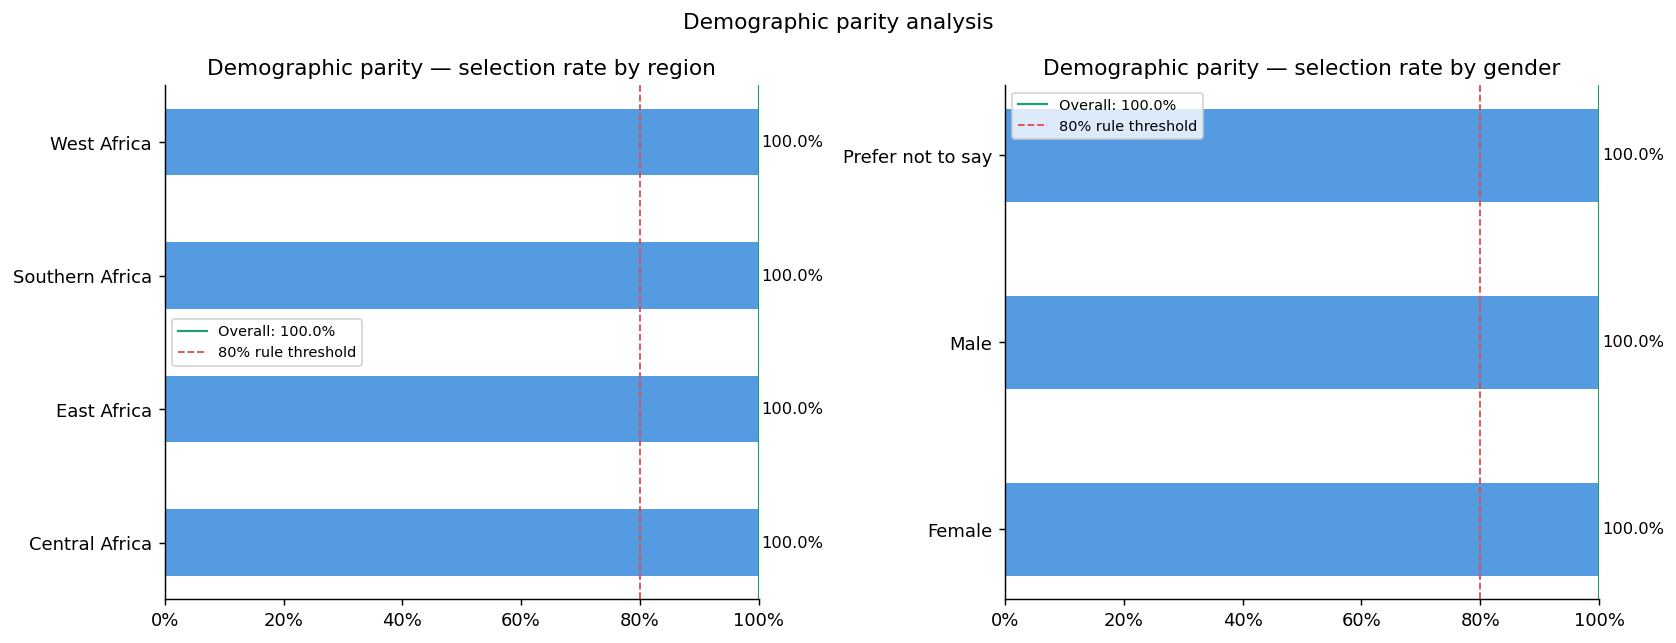

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
overall_sel = df_test["y_pred"].mean()

for ax, (fairness_df, col) in zip(
    axes,
    [(fairness_region, "region"), (fairness_gender, "gender")]
):
    rates = fairness_df["selection_rate"].sort_values()
    bars  = ax.barh(rates.index, rates.values,
                    color="#378ADD", height=0.5, alpha=0.85)

    # 80% rule band
    ax.axvline(overall_sel, color="#1D9E75", linestyle="-",
               linewidth=1.2, label=f"Overall: {overall_sel:.1%}")
    ax.axvline(overall_sel * 0.8, color="#E24B4A", linestyle="--",
               linewidth=1, label="80% rule threshold")

    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(f"Demographic parity — selection rate by {col}")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    for bar, val in zip(bars, rates.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f"{val:.1%}", va="center", fontsize=9)

plt.suptitle("Demographic parity analysis", fontsize=12)
plt.tight_layout()
plt.savefig("../artifacts/fairness/demographic_parity.png",
            dpi=150, bbox_inches="tight")
plt.show()

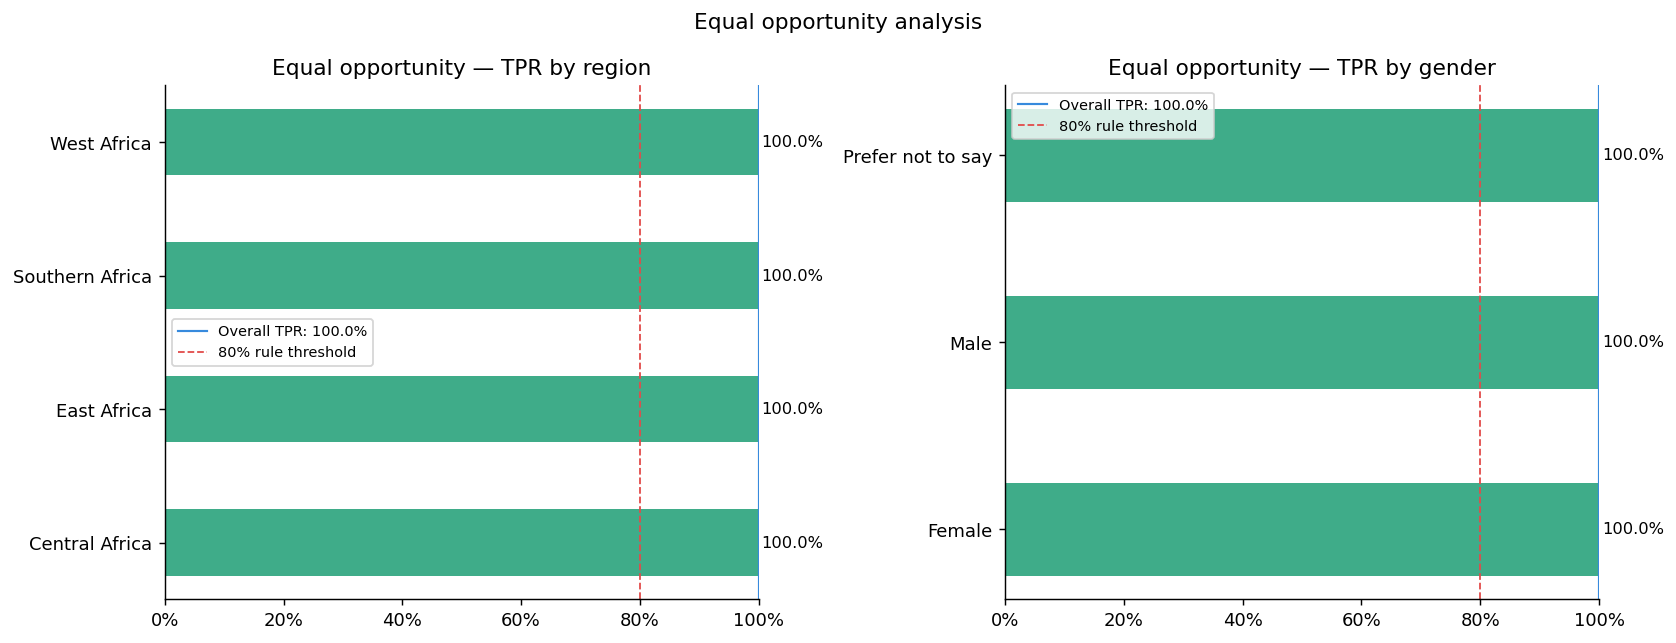

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
overall_tpr = df_test.loc[df_test["y_true"]==1, "y_pred"].mean()

for ax, (fairness_df, col) in zip(
    axes,
    [(fairness_region, "region"), (fairness_gender, "gender")]
):
    tprs = fairness_df["TPR_recall"].sort_values()
    bars = ax.barh(tprs.index, tprs.values,
                   color="#1D9E75", height=0.5, alpha=0.85)

    ax.axvline(overall_tpr, color="#378ADD", linestyle="-",
               linewidth=1.2, label=f"Overall TPR: {overall_tpr:.1%}")
    ax.axvline(overall_tpr * 0.8, color="#E24B4A", linestyle="--",
               linewidth=1, label="80% rule threshold")

    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(f"Equal opportunity — TPR by {col}")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    for bar, val in zip(bars, tprs.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f"{val:.1%}", va="center", fontsize=9)

plt.suptitle("Equal opportunity analysis", fontsize=12)
plt.tight_layout()
plt.savefig("../artifacts/fairness/equal_opportunity.png",
            dpi=150, bbox_inches="tight")
plt.show()

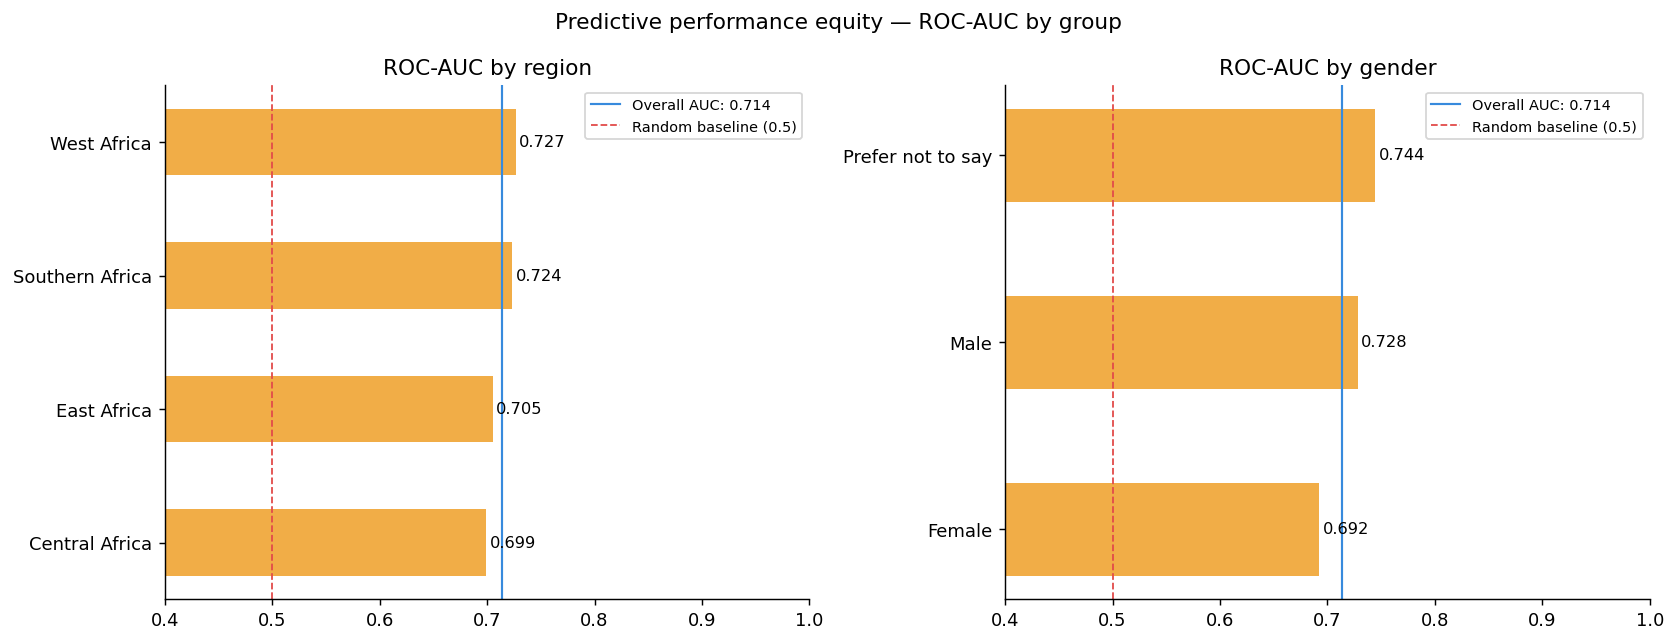

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
overall_auc = roc_auc_score(df_test["y_true"], df_test["y_proba"])

for ax, (fairness_df, col) in zip(
    axes,
    [(fairness_region, "region"), (fairness_gender, "gender")]
):
    aucs = fairness_df["roc_auc"].sort_values()
    bars = ax.barh(aucs.index, aucs.values,
                   color="#EF9F27", height=0.5, alpha=0.85)

    ax.axvline(overall_auc, color="#378ADD", linestyle="-",
               linewidth=1.2, label=f"Overall AUC: {overall_auc:.3f}")
    ax.axvline(0.5, color="#E24B4A", linestyle="--",
               linewidth=1, label="Random baseline (0.5)")

    ax.set_xlim(0.4, 1.0)
    ax.set_title(f"ROC-AUC by {col}")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    for bar, val in zip(bars, aucs.values):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=9)

plt.suptitle("Predictive performance equity — ROC-AUC by group", fontsize=12)
plt.tight_layout()
plt.savefig("../artifacts/fairness/roc_auc_by_group.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [8]:
print("=" * 65)
print("DISPARITY RATIO SUMMARY  (1.0 = no disparity)")
print("Values below 0.80 violate the 80% rule benchmark")
print("=" * 65)

for label, fairness_df in [("REGION", fairness_region),
                             ("GENDER", fairness_gender)]:
    print(f"\n{label}:")
    disp_cols = [c for c in fairness_df.columns if "disparity" in c]
    print(fairness_df[disp_cols].to_string())

    for col in disp_cols:
        min_val = fairness_df[col].min()
        if min_val < 0.80:
            metric = col.replace("_disparity", "")
            worst  = fairness_df[col].idxmin()
            print(f"  ⚠ {label} — {metric}: "
                  f"'{worst}' below 80% rule ({min_val:.3f})")
        else:
            print(f"  ✓ {label} — {col.replace('_disparity','')}: "
                  f"all groups above 80% rule")

DISPARITY RATIO SUMMARY  (1.0 = no disparity)
Values below 0.80 violate the 80% rule benchmark

REGION:
                 selection_rate_disparity  TPR_recall_disparity  precision_disparity
group                                                                               
Central Africa                        1.0                   1.0               0.9888
East Africa                           1.0                   1.0               0.9588
Southern Africa                       1.0                   1.0               1.0000
West Africa                           1.0                   1.0               0.9896
  ✓ REGION — selection_rate: all groups above 80% rule
  ✓ REGION — TPR_recall: all groups above 80% rule
  ✓ REGION — precision: all groups above 80% rule

GENDER:
                   selection_rate_disparity  TPR_recall_disparity  precision_disparity
group                                                                                 
Female                                  1.0    

In [9]:
# Check whether SHAP top features correlate with demographics
# High correlation would suggest behavioral features
# are acting as demographic proxies
shap_df = pd.read_csv("../artifacts/shap/shap_values_test.csv")

top5_features = [
    "wallet_balance_trend",
    "savings_consistency_score",
    "monthly_savings_usd",
    "has_savings_account",
    "txn_intensity",
]

print("=" * 65)
print("PROXY DETECTION — Top 5 SHAP features vs demographics")
print("Pearson correlation between feature values and group encoding")
print("Values close to 0 = feature is NOT a demographic proxy")
print("=" * 65)

for demo_col in ["region", "gender"]:
    print(f"\n{demo_col.upper()}:")
    # One-hot encode demographic for correlation
    dummies = pd.get_dummies(df_test[demo_col], prefix=demo_col)
    feat_vals = X_test[top5_features].reset_index(drop=True)

    for feat in top5_features:
        for dummy_col in dummies.columns:
            corr = feat_vals[feat].corr(
                dummies[dummy_col].reset_index(drop=True)
            )
            if abs(corr) > 0.1:  # flag anything above 0.1
                print(f"  ⚠ {feat} ↔ {dummy_col}: r={corr:.4f}")

    all_corrs = []
    for feat in top5_features:
        for dummy_col in dummies.columns:
            corr = feat_vals[feat].corr(
                dummies[dummy_col].reset_index(drop=True)
            )
            all_corrs.append(abs(corr))
    print(f"  Max |r| across all pairs: {max(all_corrs):.4f}")
    if max(all_corrs) < 0.1:
        print(f"  ✓ No strong proxy relationships detected")

PROXY DETECTION — Top 5 SHAP features vs demographics
Pearson correlation between feature values and group encoding
Values close to 0 = feature is NOT a demographic proxy

REGION:
  Max |r| across all pairs: 0.0541
  ✓ No strong proxy relationships detected

GENDER:
  Max |r| across all pairs: 0.0480
  ✓ No strong proxy relationships detected


In [10]:
report = {
    "overall": {
        "n_test":        len(df_test),
        "positive_rate": round(df_test["y_true"].mean(), 4),
        "selection_rate":round(df_test["y_pred"].mean(), 4),
        "overall_tpr":   round(overall_tpr, 4),
        "overall_auc":   round(overall_auc, 4),
    },
    "by_region": fairness_region.to_dict(),
    "by_gender": fairness_gender.to_dict(),
}

import json
with open("../artifacts/fairness/fairness_report.json", "w") as f:
    json.dump(report, f, indent=2)

print("✓ Saved: artifacts/fairness/fairness_report.json")
print("\nFairness analysis complete.")
print("\nArtifacts produced:")
for p in sorted(Path("../artifacts/fairness").iterdir()):
    print(f"  {p.name}")

✓ Saved: artifacts/fairness/fairness_report.json

Fairness analysis complete.

Artifacts produced:
  demographic_parity.png
  equal_opportunity.png
  fairness_by_gender.csv
  fairness_by_region.csv
  fairness_report.json
  roc_auc_by_group.png


## Fairness analysis summary — paper language

**Demographic parity:** Selection rates across regional and
gender groups are compared against the 80% rule benchmark.
Groups falling below the threshold are flagged for discussion.

**Equal opportunity:** True positive rates across groups
measure whether creditworthy borrowers are equally served
regardless of demographic membership.

**Proxy detection:** Pearson correlations between top SHAP
features and demographic encodings assess whether behavioral
features inadvertently encode demographic information.

**Limitation:** This analysis uses synthetically generated
data with demographic distributions that do not perfectly
reflect any specific national population. Findings should
be interpreted as methodological demonstrations rather than
empirical claims about real lending systems. Validation on
real-world data remains necessary before deployment.

In [12]:
from pathlib import Path

required = [
    "artifacts/model/pipeline.pkl",
    "artifacts/model/shap_explainer.pkl",
    "artifacts/model/X_test.csv",
    "artifacts/model/threshold.json",
    "artifacts/shap/shap_values_test.csv",
    "artifacts/fairness/fairness_report.json",
]

print("Artifact checklist:")
for path in required:
    exists = Path(f"../{path}").exists()
    status = "✓" if exists else "✗ MISSING"
    print(f"  {status}  {path}")

Artifact checklist:
  ✓  artifacts/model/pipeline.pkl
  ✓  artifacts/model/shap_explainer.pkl
  ✓  artifacts/model/X_test.csv
  ✓  artifacts/model/threshold.json
  ✓  artifacts/shap/shap_values_test.csv
  ✓  artifacts/fairness/fairness_report.json


In [13]:
print("FAIRNESS ANALYSIS AT MULTIPLE OPERATING THRESHOLDS")
print("=" * 60)

# Realistic approval rate thresholds
thresholds_to_test = {
    "Low approval (30%)":    np.percentile(y_proba, 70),
    "Medium approval (50%)": np.percentile(y_proba, 50),
    "High approval (70%)":   np.percentile(y_proba, 30),
    "Original optimal":      THRESHOLD,
}

for label, thresh in thresholds_to_test.items():
    y_pred_t = (y_proba >= thresh).astype(int)
    approval_rate = y_pred_t.mean()

    print(f"\n{label} (threshold={thresh:.3f}, approval={approval_rate:.1%})")

    df_test["y_pred_t"] = y_pred_t
    for col in ["region", "gender"]:
        rates = df_test.groupby(col)["y_pred_t"].mean()
        max_rate = rates.max()
        min_rate = rates.min()
        disparity = min_rate / max_rate if max_rate > 0 else 1.0
        worst_group = rates.idxmin()
        print(f"  {col}: min={min_rate:.3f} max={max_rate:.3f} "
              f"disparity={disparity:.3f} "
              f"worst='{worst_group}'")
        if disparity < 0.80:
            print(f"  ⚠ VIOLATION at {label}")
        else:
            print(f"  ✓ passes 80% rule")

FAIRNESS ANALYSIS AT MULTIPLE OPERATING THRESHOLDS

Low approval (30%) (threshold=0.621, approval=30.0%)
  region: min=0.273 max=0.334 disparity=0.818 worst='West Africa'
  ✓ passes 80% rule
  gender: min=0.295 max=0.317 disparity=0.932 worst='Male'
  ✓ passes 80% rule

Medium approval (50%) (threshold=0.509, approval=50.0%)
  region: min=0.428 max=0.528 disparity=0.811 worst='Central Africa'
  ✓ passes 80% rule
  gender: min=0.497 max=0.524 disparity=0.947 worst='Female'
  ✓ passes 80% rule

High approval (70%) (threshold=0.433, approval=70.0%)
  region: min=0.652 max=0.722 disparity=0.903 worst='Central Africa'
  ✓ passes 80% rule
  gender: min=0.693 max=0.709 disparity=0.978 worst='Male'
  ✓ passes 80% rule

Original optimal (threshold=0.151, approval=100.0%)
  region: min=1.000 max=1.000 disparity=1.000 worst='Central Africa'
  ✓ passes 80% rule
  gender: min=1.000 max=1.000 disparity=1.000 worst='Female'
  ✓ passes 80% rule
